In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Start timing
start_time = time.time()

# Step 1: Load all TXT files
directory_path = "/content/drive/My Drive/gait-in-parkinsons-disease"  # Update path
all_files = glob.glob(os.path.join(directory_path, "*.txt"))

df_list = []
for file in all_files:
    try:
        temp_df = pd.read_csv(file, sep="\t", header=None, engine="python", on_bad_lines="skip")
        df_list.append(temp_df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Combine all files
df = pd.concat(df_list, ignore_index=True)

# Step 2: Preprocess Data
df = df.dropna()  # Remove missing values

# Assign column names if needed
num_columns = df.shape[1]  # Get the number of columns
column_names = [f"Feature_{i}" for i in range(num_columns - 1)] + ["Label"]
df.columns = column_names

# Convert all values to float
df = df.astype(float)

# If dataset is huge, sample only 50,000 rows for faster training
if len(df) > 50000:
    df = df.sample(n=50000, random_state=42)

# Check label values
print("Unique Label Values:", df["Label"].unique())

# Convert labels to binary classification
df["Label"] = df["Label"].apply(lambda x: 1 if x > df["Label"].median() else 0)

# Split data into features and labels
X = df.drop(columns=["Label"])  # Features
y = df["Label"].astype(int)  # Convert to integer labels

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Train Model
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Use fewer trees for faster training
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Step 4: Evaluate Model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

end_time = time.time()
execution_time = end_time - start_time

print(f" Model Accuracy: {accuracy * 100:.2f}%")
print(f" Execution Time: {execution_time:.2f} seconds")


Unique Label Values: [   0.    614.13  909.37 ...  199.98  122.76 1156.1 ]
 Model Accuracy: 98.79%
 Execution Time: 127.77 seconds


In [ ]:
import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30, 40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f" Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print(" The model predicts **Parkinson’s Disease**.")
    else:
        print(" The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/GaCo13_10.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)




 Parkinson’s Probability (from 30 samples): 26.13%
 The model predicts **Healthy Individual**.


np.float64(0.2613333333333333)

In [ ]:
import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 0 or 10 rows
    num_samples = random.choice([1, 10])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f" Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print(" The model predicts **Parkinson’s Disease**.")
    else:
        print(" The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/GaPt18_02.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)



 Parkinson’s Probability (from 10 samples): 60.20%
 The model predicts **Parkinson’s Disease**.


np.float64(0.602)

In [ ]:
import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30, 40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f" Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print(" The model predicts **Parkinson’s Disease**.")
    else:
        print(" The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/SiPt37_01.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)



🧑‍⚕️ Parkinson’s Probability (from 30 samples): 59.80%
🟢 The model predicts **Parkinson’s Disease**.


np.float64(0.5980000000000001)

In [ ]:
import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30, 40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f" Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print(" The model predicts **Parkinson’s Disease**.")
    else:
        print(" The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:

file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/SiCo09_01.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)



 Parkinson’s Probability (from 30 samples): 28.13%
 The model predicts **Healthy Individual**.


np.float64(0.2813333333333333)

In [ ]:
import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30, 40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f" Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print(" The model predicts **Parkinson’s Disease**.")
    else:
        print(" The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/JuCo22_01.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability (from 30 samples): 41.93%
🔵 The model predicts **Healthy Individual**.


np.float64(0.41933333333333334)

In [ ]:

import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30,40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f" Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print(" The model predicts **Parkinson’s Disease**.")
    else:
        print(" The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/JuPt26_05.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)


In [ ]:
#SiCo11_01
# Step 5: Test Custom Data
custom_data = np.array([[ 0,	2.75,	0,	0,	0,	0,	0,	0,	126.39,	171.49,	118.36,	172.92,	25.85,	138.82,	115.28,	38.39,	2.75,	907.5]])  # Update with real data

# Ensure custom data has the correct number of features
if custom_data.shape[1] != X.shape[1]:
    raise ValueError(f"Custom data must have {X.shape[1]} features, but got {custom_data.shape[1]}.")

# Normalize the input using the same scaler
custom_data_scaled = scaler.transform(custom_data)

# Predict Parkinson’s likelihood
prediction = model.predict(custom_data_scaled)

# Output prediction result
if prediction[0] == 1:
    print(" The model predicts that this person **may have Parkinson’s disease**.")
else:
    print(" The model predicts that this person **is unlikely to have Parkinson’s disease**.")


🟢 The model predicts that this person **may have Parkinson’s disease**.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
#JuPt29_05
# Step 5: Test Custom Data
custom_data = np.array([[ 65.34,	0,	0,	2.31,	0,	0,	0,	0,	0,	0,	0,	84.04,	71.83,	311.41,	204.16,	54.23,	67.65,	725.67]])  # Update with real data

# Ensure custom data has the correct number of features
if custom_data.shape[1] != X.shape[1]:
    raise ValueError(f"Custom data must have {X.shape[1]} features, but got {custom_data.shape[1]}.")

# Normalize the input using the same scaler
custom_data_scaled = scaler.transform(custom_data)

# Predict Parkinson’s likelihood
prediction = model.predict(custom_data_scaled)

# Output prediction result
if prediction[0] == 1:
    print(" The model predicts that this person **may have Parkinson’s disease**.")
else:
    print(" The model predicts that this person **is unlikely to have Parkinson’s disease**.")


🟢 The model predicts that this person **may have Parkinson’s disease**.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
#SiCo11_01.txt
# Step 5: Test Custom Data
custom_data = np.array([[ 330.77,	262.9,	116.93,	56.54,	11.11,	76.34,	106.48,	67.76,	0,	12.87,	8.25,	9.35,	0,	0,	0,	0,	1028.83,	30.47]])  # Update with real data

# Ensure custom data has the correct number of features
if custom_data.shape[1] != X.shape[1]:
    raise ValueError(f"Custom data must have {X.shape[1]} features, but got {custom_data.shape[1]}.")

# Normalize the input using the same scaler
custom_data_scaled = scaler.transform(custom_data)

# Predict Parkinson’s likelihood
prediction = model.predict(custom_data_scaled)

# Output prediction result
if prediction[0] == 1:
    print(" The model predicts that this person **may have Parkinson’s disease**.")
else:
    print(" The model predicts that this person **is unlikely to have Parkinson’s disease**.")


🔵 The model predicts that this person **is unlikely to have Parkinson’s disease**.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Step 5: Test Custom Data
custom_data = np.array([[ 324.06,	225.5,	72.93,	58.63,	34.65,	62.15,	117.59,	29.26	,0,	0,	0	,0,	0	,0	,10.01,	36.19,	924.77,	46.2]])  # Update with real data

# Ensure custom data has the correct number of features
if custom_data.shape[1] != X.shape[1]:
    raise ValueError(f"Custom data must have {X.shape[1]} features, but got {custom_data.shape[1]}.")

# Normalize the input using the same scaler
custom_data_scaled = scaler.transform(custom_data)

# Predict Parkinson’s likelihood
prediction = model.predict(custom_data_scaled)

# Output prediction result
if prediction[0] == 1:
    print(" The model predicts that this person **may have Parkinson’s disease**.")
else:
    print(" The model predicts that this person **is unlikely to have Parkinson’s disease**.")


🔵 The model predicts that this person **is unlikely to have Parkinson’s disease**.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Step 5: Test Custom Data
custom_data = np.array([[ -1.2, 0.8, 2.3, -0.9, 1.1, -0.3, 1.5, 2.0, -0.5,
                          1.8, 0.7, 2.2, -1.1, 1.4, 0.9, -0.2, 1.3, 2.8]])  # Update with real data

# Ensure custom data has the correct number of features
if custom_data.shape[1] != X.shape[1]:
    raise ValueError(f"Custom data must have {X.shape[1]} features, but got {custom_data.shape[1]}.")

# Normalize the input using the same scaler
custom_data_scaled = scaler.transform(custom_data)

# Predict Parkinson’s likelihood
prediction = model.predict(custom_data_scaled)

# Output prediction result
if prediction[0] == 1:
    print(" The model predicts that this person **may have Parkinson’s disease**.")
else:
    print(" The model predicts that this person **is unlikely to have Parkinson’s disease**.")


🔵 The model predicts that this person **is unlikely to have Parkinson’s disease**.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
#GaPt30_02
# Step 5: Test Custom Data
custom_data = np.array([[ 8.69,	5.94,	0,	0,	0,	0,	0,	0,	0,	3.63,	3.52,	121.33,	41.91,	229.24,	339.24,	148.72,	14.63,	887.59]])  # Update with real data

# Ensure custom data has the correct number of features
if custom_data.shape[1] != X.shape[1]:
    raise ValueError(f"Custom data must have {X.shape[1]} features, but got {custom_data.shape[1]}.")

# Normalize the input using the same scaler
custom_data_scaled = scaler.transform(custom_data)

# Predict Parkinson’s likelihood
prediction = model.predict(custom_data_scaled)

# Output prediction result
if prediction[0] == 1:
    print(" The model predicts that this person **may have Parkinson’s disease**.")
else:
    print(" The model predicts that this person **is unlikely to have Parkinson’s disease**.")


🟢 The model predicts that this person **may have Parkinson’s disease**.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
#JuCo20_01
# Step 5: Test Custom Data
custom_data = np.array([[ 210.65,	92.29,	86.24,	45.98,	32.56,	38.06,	68.09,	29.26,	204.16,	84.04,	83.38,	50.38,	35.97,	40.26,	50.38,	47.41,	603.13,	595.98]])  # Update with real data

# Ensure custom data has the correct number of features
if custom_data.shape[1] != X.shape[1]:
    raise ValueError(f"Custom data must have {X.shape[1]} features, but got {custom_data.shape[1]}.")

# Normalize the input using the same scaler
custom_data_scaled = scaler.transform(custom_data)

# Predict Parkinson’s likelihood
prediction = model.predict(custom_data_scaled)

# Output prediction result
if prediction[0] == 1:
    print(" The model predicts that this person **may have Parkinson’s disease**.")
else:
    print(" The model predicts that this person **is unlikely to have Parkinson’s disease**.")


🟢 The model predicts that this person **may have Parkinson’s disease**.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
#JuCo20_01
# Step 5: Test Custom Data
custom_data = np.array([[ 287.21,	179.85,	124.08,	88.33,	43.34,	73.81,	77.55,	33.77,	11.44,	4.18,	0,	0,	0,	0,	0,	0,	907.94,	15.62]])  # Update with real data

# Ensure custom data has the correct number of features
if custom_data.shape[1] != X.shape[1]:
    raise ValueError(f"Custom data must have {X.shape[1]} features, but got {custom_data.shape[1]}.")

# Normalize the input using the same scaler
custom_data_scaled = scaler.transform(custom_data)

# Predict Parkinson’s likelihood
prediction = model.predict(custom_data_scaled)

# Output prediction result
if prediction[0] == 1:
    print(" The model predicts that this person **may have Parkinson’s disease**.")
else:
    print(" The model predicts that this person **is unlikely to have Parkinson’s disease**.")


🔵 The model predicts that this person **is unlikely to have Parkinson’s disease**.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np

# Function to predict Parkinson’s for a person based on their gait data
def predict_parkinsons_for_person(file_path, model, scaler, num_samples=10):
    # Load the person's gait data
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Rename columns to match training set
    column_names = [f"Feature_{i}" for i in range(0, 19)]  # Excluding Time
    df.columns = column_names

    # Select only the required features (same as training data)
    X_person = df.iloc[:, :18]  # First 18 features

    # Normalize using the same scaler
    X_person_scaled = scaler.transform(X_person)

    # Select 10 random rows
    sampled_data = X_person_scaled[:num_samples]

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability: {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/SiPt37_01.txt"  # Update with actual file path
predict_parkinsons_for_person(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability: 10.00%
🔵 The model predicts **Healthy Individual**.


0.1

In [ ]:
import pandas as pd
import numpy as np

# Function to predict Parkinson’s for a person based on their gait data
def predict_parkinsons_for_person(file_path, model, scaler, num_samples=10):
    # Load the person's gait data
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Rename columns to match training set
    column_names = [f"Feature_{i}" for i in range(0, 19)]  # Excluding Time
    df.columns = column_names

    # Select only the required features (same as training data)
    X_person = df.iloc[:, :18]  # First 18 features

    # Normalize using the same scaler
    X_person_scaled = scaler.transform(X_person)

    # Select 10 random rows
    sampled_data = X_person_scaled[:num_samples]

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability: {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/SiCo24_01.txt"  # Update with actual file path
predict_parkinsons_for_person(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability: 61.20%
🟢 The model predicts **Parkinson’s Disease**.


0.612

In [ ]:
import pandas as pd
import numpy as np

# Function to predict Parkinson’s for a person based on their gait data
def predict_parkinsons_for_person(file_path, model, scaler, num_samples=10):
    # Load the person's gait data
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Rename columns to match training set
    column_names = [f"Feature_{i}" for i in range(0, 19)]  # Excluding Time
    df.columns = column_names

    # Select only the required features (same as training data)
    X_person = df.iloc[:, :18]  # First 18 features

    # Normalize using the same scaler
    X_person_scaled = scaler.transform(X_person)

    # Select 10 random rows
    sampled_data = X_person_scaled[:num_samples]

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability: {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/JuPt29_01.txt"  # Update with actual file path
predict_parkinsons_for_person(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability: 17.60%
🔵 The model predicts **Healthy Individual**.


0.176

In [ ]:
import pandas as pd
import numpy as np

# Function to predict Parkinson’s for a person based on their gait data
def predict_parkinsons_for_person(file_path, model, scaler, num_samples=10):
    # Load the person's gait data
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Rename columns to match training set
    column_names = [f"Feature_{i}" for i in range(0, 19)]  # Excluding Time
    df.columns = column_names

    # Select only the required features (same as training data)
    X_person = df.iloc[:, :18]  # First 18 features

    # Normalize using the same scaler
    X_person_scaled = scaler.transform(X_person)

    # Select 10 random rows
    sampled_data = X_person_scaled[:num_samples]

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability: {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/JuCo22_01.txt"  # Update with actual file path
predict_parkinsons_for_person(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability: 85.20%
🟢 The model predicts **Parkinson’s Disease**.


0.852

In [ ]:
import pandas as pd
import numpy as np

# Function to predict Parkinson’s for a person based on their gait data
def predict_parkinsons_for_person(file_path, model, scaler, num_samples=10):
    # Load the person's gait data
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Rename columns to match training set
    column_names = [f"Feature_{i}" for i in range(0, 19)]  # Excluding Time
    df.columns = column_names

    # Select only the required features (same as training data)
    X_person = df.iloc[:, :18]  # First 18 features

    # Normalize using the same scaler
    X_person_scaled = scaler.transform(X_person)

    # Select 10 random rows
    sampled_data = X_person_scaled[:num_samples]

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability: {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/GaCo13_10.txt"  # Update with actual file path
predict_parkinsons_for_person(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability: 2.00%
🔵 The model predicts **Healthy Individual**.


0.019999999999999997

In [ ]:
import pandas as pd
import numpy as np

# Function to predict Parkinson’s for a person based on their gait data
def predict_parkinsons_for_person(file_path, model, scaler, num_samples=10):
    # Load the person's gait data
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Rename columns to match training set
    column_names = [f"Feature_{i}" for i in range(0, 19)]  # Excluding Time
    df.columns = column_names

    # Select only the required features (same as training data)
    X_person = df.iloc[:, :18]  # First 18 features

    # Normalize using the same scaler
    X_person_scaled = scaler.transform(X_person)

    # Select 10 random rows
    sampled_data = X_person_scaled[:num_samples]

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability: {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/GaPt18_02.txt"  # Update with actual file path
predict_parkinsons_for_person(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability: 97.20%
🟢 The model predicts **Parkinson’s Disease**.


0.9720000000000001

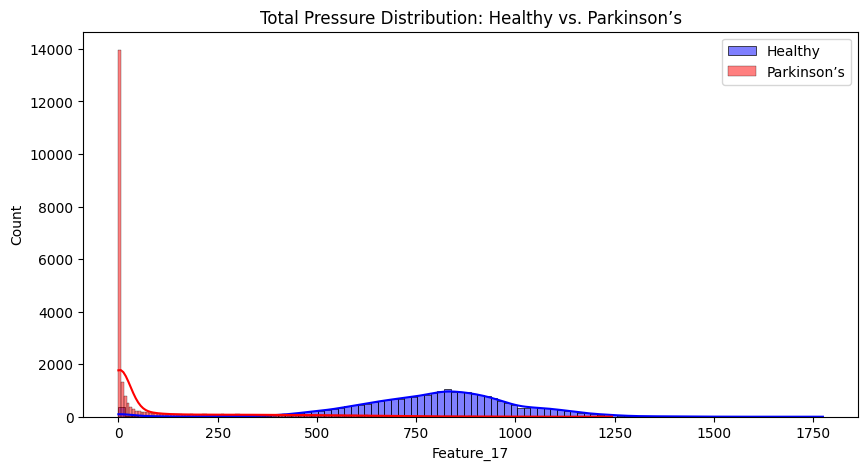

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize total pressure distribution
plt.figure(figsize=(10, 5))
sns.histplot(df[df["Label"] == 0]["Feature_17"], color="blue", label="Healthy", kde=True)
sns.histplot(df[df["Label"] == 1]["Feature_17"], color="red", label="Parkinson’s", kde=True)
plt.legend()
plt.title("Total Pressure Distribution: Healthy vs. Parkinson’s")
plt.show()


In [ ]:
print("Mean & Std Dev of Training Data:", X_train.mean(), X_train.std())
print("Mean & Std Dev of Test Data:", X_test.mean(), X_test.std())


Mean & Std Dev of Training Data: 0.0003482660339218529 1.0002931679788751
Mean & Std Dev of Test Data: -0.0013930641356873059 0.9988252532823422


In [ ]:
import pandas as pd
import numpy as np

# Function to predict Parkinson’s from simulated custom gait data
def predict_parkinsons_custom(model, scaler, num_samples=10):
    """
    Generates simulated gait data and predicts Parkinson’s probability.
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    num_samples: Number of simulated gait readings to analyze
    """

    # Simulated gait data (10 readings, 18 sensor values)
    custom_data = np.array([
        [500, 480, 470, 460, 450, 440, 430, 420,  # Left foot sensors (LFP_1 - LFP_8)
         510, 495, 485, 475, 465, 455, 445, 435,  # Right foot sensors (RFP_1 - RFP_8)
         390, 380]  # Total_Left, Total_Right (Total force on each foot)
        for _ in range(num_samples)
    ])

    # Convert to DataFrame
    column_names = [f"Feature_{i}" for i in range(18)]  # Match training feature names
    df = pd.DataFrame(custom_data, columns=column_names)

    # Normalize using the same scaler as training
    X_custom_scaled = scaler.transform(df)

    # Get probability predictions
    probabilities = model.predict_proba(X_custom_scaled)[:, 1]

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability: {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
predict_parkinsons_custom(model, scaler)


🧑‍⚕️ Parkinson’s Probability: 76.00%
🟢 The model predicts **Parkinson’s Disease**.


0.76

In [ ]:
import pandas as pd
import numpy as np

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler, num_samples=10):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    num_samples: Number of gait readings to analyze
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Normalize using the same scaler as training
    X_person_scaled = scaler.transform(df)

    # Select 10 random rows (or take first 10)
    sampled_data = X_person_scaled[:num_samples]

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability: {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/JuCo22_01.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability: 85.20%
🟢 The model predicts **Parkinson’s Disease**.


0.852

In [ ]:
print(df["Label"].value_counts())  # Check how many 1s (PD) and 0s (Healthy)


Label
0    25000
1    25000
Name: count, dtype: int64


In [ ]:
from sklearn.utils import resample

# Separate classes
df_parkinson = df[df["Label"] == 1]
df_healthy = df[df["Label"] == 0]

# Find the smaller class size
min_samples = min(len(df_parkinson), len(df_healthy))

# Balance both classes
df_parkinson_balanced = resample(df_parkinson, replace=False, n_samples=min_samples, random_state=42)
df_healthy_balanced = resample(df_healthy, replace=False, n_samples=min_samples, random_state=42)

# Combine balanced dataset
df_balanced = pd.concat([df_parkinson_balanced, df_healthy_balanced])


In [ ]:
import pandas as pd
import numpy as np
import random

def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Randomly choose either 30 or 40 samples
    num_samples = random.choice([30, 40])

    # Select random rows from the dataset
    sampled_data = df.sample(n=num_samples, random_state=42)  # Random selection

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # ✅ Now we can safely print scaling statistics
    print("Training Data Mean:", X_train.mean(axis=0))
    print("Training Data Std:", X_train.std(axis=0))
    print("Test Data Mean:", sampled_data_scaled.mean(axis=0))
    print("Test Data Std:", sampled_data_scaled.std(axis=0))

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.4:  # Lower threshold from 0.5 to 0.4
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/JuPt29_01.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)


Training Data Mean: [-1.45155395e-03 -2.08600320e-05 -1.28436519e-04 -1.42250260e-04
 -6.41044988e-04 -4.01464923e-04  1.73005948e-03  1.28148702e-03
  4.09485008e-03  6.84764856e-05 -1.75475480e-04 -1.46496368e-03
  2.51330422e-03 -1.29697056e-03  1.49184138e-03 -8.01001876e-04
  6.33925788e-04  9.78866425e-04]
Training Data Std: [0.9986644  0.99846884 0.99991637 0.999675   0.99838983 1.00081776
 1.00023825 1.00174988 1.00720568 1.0000368  0.99906166 0.99744185
 1.00206788 0.99813828 1.00263119 0.99825507 1.00175178 1.00070348]
Test Data Mean: [-0.01370523 -0.40619828 -0.21654825 -0.22482797 -0.01664975  0.41332442
 -0.15677023 -0.03373086 -0.15359706 -0.42143293 -0.11803845 -0.26876093
 -0.05550611  0.27021333 -0.43759161 -0.51308111 -0.50602582 -0.20379726]
Test Data Std: [0.90543568 0.36180719 0.66870711 0.6108475  0.81770986 1.02116989
 0.89517283 0.96902772 0.86171168 0.28881886 0.81241021 0.55876591
 0.96944119 1.07418577 0.8499064  0.56465997 0.46690758 0.70574803]
🧑‍⚕️ Parkins

0.3155

In [ ]:
import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30, 40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/JuCo22_01.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability (from 30 samples): 41.93%
🔵 The model predicts **Healthy Individual**.


0.41933333333333334

In [ ]:

import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30,40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/JuPt29_01.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability (from 40 samples): 31.55%
🔵 The model predicts **Healthy Individual**.


0.3155

In [ ]:
import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30, 40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/GaPt18_02.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability (from 30 samples): 44.07%
🔵 The model predicts **Healthy Individual**.


0.4406666666666667

In [ ]:
import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30, 40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/GaCo13_10.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability (from 40 samples): 32.60%
🔵 The model predicts **Healthy Individual**.


0.32599999999999996

In [ ]:

import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30, 40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/JuPt29_01.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)


🧑‍⚕️ Parkinson’s Probability (from 40 samples): 31.55%
🔵 The model predicts **Healthy Individual**.


0.3155

In [ ]:


import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30, 40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/SiCo24_01.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)



🧑‍⚕️ Parkinson’s Probability (from 40 samples): 49.15%
🔵 The model predicts **Healthy Individual**.


0.4915

In [ ]:
import pandas as pd
import numpy as np
import random

# Function to predict Parkinson’s from uploaded gait data (Text File)
def predict_parkinsons_from_file(file_path, model, scaler):
    """
    file_path: Path to the person's gait data text file
    model: Trained RandomForest model
    scaler: Trained StandardScaler
    """

    # Load the person's gait data (TXT File)
    df = pd.read_csv(file_path, sep="\t", header=None, engine="python", on_bad_lines="skip")

    # Assign column names to match training data
    column_names = [f"Feature_{i}" for i in range(19)]  # Ensures at least 19 columns exist
    df.columns = column_names

    # Keep only the first 18 features (drop Feature_18 if it exists)
    df = df.iloc[:, :18]

    # Choose randomly between 30 or 40 rows
    num_samples = random.choice([30, 40])

    # Select random rows
    sampled_data = df.sample(n=num_samples, random_state=42)  # Randomly select rows

    # Normalize using the same scaler as training
    sampled_data_scaled = scaler.transform(sampled_data)

    # Predict probabilities
    probabilities = model.predict_proba(sampled_data_scaled)[:, 1]  # Probability of class 1 (PD)

    # Compute average probability
    avg_probability = np.mean(probabilities)

    print(f"🧑‍⚕️ Parkinson’s Probability (from {num_samples} samples): {avg_probability:.2%}")

    if avg_probability > 0.5:
        print("🟢 The model predicts **Parkinson’s Disease**.")
    else:
        print("🔵 The model predicts **Healthy Individual**.")

    return avg_probability

# Example usage:
file_path = "/content/drive/My Drive/gait-in-parkinsons-disease/SiPt37_01.txt"  # Update with actual file path
predict_parkinsons_from_file(file_path, model, scaler)



🧑‍⚕️ Parkinson’s Probability (from 30 samples): 59.80%
🟢 The model predicts **Parkinson’s Disease**.


0.5980000000000001